In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =====================================
# 📘 KNN Classification with SMOTE-Tomek (Cell-by-Cell)
# =====================================

# 🧩 Cell 1: Import Libraries
import pandas as pd
import numpy as np
import time
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, auc, classification_report
)
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import label_binarize
from imblearn.combine import SMOTETomek

In [3]:
# =====================================
# Cell 2: Load Dataset
# =====================================
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

print("✅ Data Loaded Successfully!")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

✅ Data Loaded Successfully!
Train shape: (329623, 13)
Test shape: (82406, 13)


In [4]:
# =====================================
# Cell 3: Split Features & Target
# =====================================
target_col = "PM2.5_level"
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col]
X_test  = df_test.drop(columns=[target_col])
y_test  = df_test[target_col]

In [5]:
# =====================================
# Cell 4: Apply SMOTE-Tomek (Resampling)
# =====================================
from collections import Counter
from imblearn.combine import SMOTETomek

# ตรวจสอบ class distribution ก่อน oversampling
class_counts = Counter(y_train)
print("\nBefore SMOTE-Tomek:", class_counts)

# หา class ที่มีจำนวนมากที่สุด (majority)
majority_class_count = max(class_counts.values())

# คำนวณเป้าหมาย = 50% ของจำนวนคลาสใหญ่สุด
target_size = int(majority_class_count * 0.5)

# สร้าง sampling strategy เฉพาะสำหรับ class 2 และ 3
sampling_strategy = {
    cls: target_size for cls in [2, 3] if class_counts[cls] < target_size
}

print("Dynamic sampling strategy:", sampling_strategy)

# ใช้ SMOTE-Tomek ตาม strategy ที่คำนวณได้
smote_tomek = SMOTETomek(
    sampling_strategy=sampling_strategy,
    random_state=42
)

# ทำ oversampling และ undersampling
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)

# ตรวจสอบผลลัพธ์หลัง resampling
print("\nAfter SMOTE-Tomek:", Counter(y_resampled))


Before SMOTE-Tomek: Counter({5: 128801, 4: 73062, 1: 64314, 2: 33504, 3: 29942})
Dynamic sampling strategy: {2: 64400, 3: 64400}

After SMOTE-Tomek: Counter({5: 123151, 4: 65305, 3: 61604, 1: 61200, 2: 60907})


In [6]:
# =====================================
# 🧩 Cell 5: 10-Fold Cross Validation + Mean ± SD
# =====================================
import os

kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results = []
accuracy_list, precision_list, recall_list, f1_list, auc_scores = [], [], [], [], []

print("=== 10-Fold Cross Validation Results ===")

X_resampled = np.array(X_resampled)
y_resampled = np.array(y_resampled)
classes = np.unique(y_resampled)

start_time = time.time()

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_resampled, y_resampled), 1):
    X_tr, X_val = X_resampled[train_idx], X_resampled[val_idx]
    y_tr, y_val = y_resampled[train_idx], y_resampled[val_idx]

    model = KNeighborsClassifier(n_jobs=-1)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

    y_val_bin = label_binarize(y_val, classes=sorted(classes))
    y_pred_bin = label_binarize(y_pred, classes=sorted(classes))
    fold_auc = roc_auc_score(y_val_bin, y_pred_bin, average="weighted", multi_class="ovr")

    results.append([fold, acc, prec, rec, f1, fold_auc])
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    auc_scores.append(fold_auc)

# 🧾 สรุปผลลัพธ์แต่ละ Fold
cv_df = pd.DataFrame(results, columns=["Fold", "Accuracy", "Precision", "Recall", "F1", "AUC_ROC"])
print(cv_df)

# ✅ คำนวณค่า Mean ± SD
acc_mean, acc_sd = np.mean(accuracy_list), np.std(accuracy_list)
prec_mean, prec_sd = np.mean(precision_list), np.std(precision_list)
rec_mean, rec_sd = np.mean(recall_list), np.std(recall_list)
f1_mean, f1_sd = np.mean(f1_list), np.std(f1_list)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

# 📊 แสดงผลสรุป Mean ± SD
print("\n📊 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")

end_time = time.time()
print(f"\n⏱ Completed in {end_time - start_time:.2f} seconds")



=== 10-Fold Cross Validation Results ===
   Fold  Accuracy  Precision    Recall        F1   AUC_ROC
0     1  0.776527   0.784199  0.776527  0.776400  0.862155
1     2  0.772980   0.780194  0.772980  0.772911  0.859829
2     3  0.780181   0.787017  0.780181  0.780118  0.864345
3     4  0.777897   0.785554  0.777897  0.778024  0.863208
4     5  0.776285   0.783173  0.776285  0.776063  0.861963
5     6  0.774592   0.781464  0.774592  0.774418  0.860915
6     7  0.775613   0.782541  0.775613  0.775452  0.861481
7     8  0.776279   0.782246  0.776279  0.775595  0.861794
8     9  0.774129   0.781358  0.774129  0.773947  0.860509
9    10  0.776575   0.783528  0.776575  0.776292  0.862255

📊 Cross-validation (10 folds) Metrics (Mean ± SD):
Accuracy : 0.776 ± 0.002
Precision: 0.783 ± 0.002
Recall   : 0.776 ± 0.002
F1-score : 0.776 ± 0.002
AUC-ROC  : 0.862 ± 0.001

⏱ Completed in 156.92 seconds


In [7]:
# 💾 (Optional) บันทึก mean+sd ลงไฟล์ CSV
cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

base_path = '/content/drive/MyDrive/Senior_Project/roc/KNN_Roc/2-3/MeanSD/'
summary_path = base_path + "2-3KNN_tomek_MeanSD.csv"

# ✅ ตรวจสอบและสร้างโฟลเดอร์ (กัน error Directory not found)
os.makedirs(base_path, exist_ok=True)

cv_summary.to_csv(summary_path, index=False)
print(f"💾 Mean + SD summary saved to {summary_path}")

💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/KNN_Roc/2-3/MeanSD/2-3KNN_tomek_MeanSD.csv


In [8]:
# =====================================
#Cell 6: Final Testing & Report
# =====================================
model.fit(X_resampled, y_resampled)
y_pred_test = model.predict(X_test)

test_acc = accuracy_score(y_test, y_pred_test)
test_prec = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_rec = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')

y_test_bin = label_binarize(y_test, classes=sorted(classes))
y_pred_test_bin = label_binarize(y_pred_test, classes=sorted(classes))
test_auc = roc_auc_score(y_test_bin, y_pred_test_bin, average="weighted", multi_class="ovr")

print(f"\n📈 Test Set Metrics:")
print(f"Accuracy: {test_acc:.3f}, Precision: {test_prec:.3f}, Recall: {test_rec:.3f}, F1: {test_f1:.3f}, AUC: {test_auc:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, digits=2))

print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(



📈 Test Set Metrics:
Accuracy: 0.704, Precision: 0.730, Recall: 0.704, F1: 0.713, AUC: 0.819

Classification Report:
              precision    recall  f1-score   support

           1       0.81      0.74      0.77     16078
           2       0.37      0.48      0.42      8376
           3       0.34      0.48      0.40      7486
           4       0.69      0.54      0.61     18265
           5       0.90      0.89      0.89     32201

    accuracy                           0.70     82406
   macro avg       0.62      0.63      0.62     82406
weighted avg       0.73      0.70      0.71     82406

Confusion Matrix:
[[11842  3275   766   138    57]
 [ 2015  4030  1917   386    28]
 [  463  2041  3611  1226   145]
 [  262  1355  3694  9954  3000]
 [   30   180   616  2790 28585]]


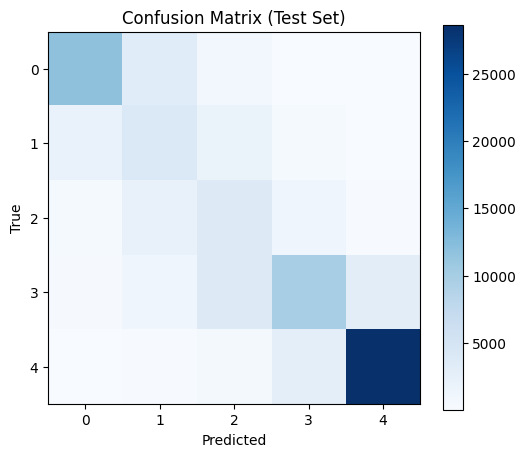

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


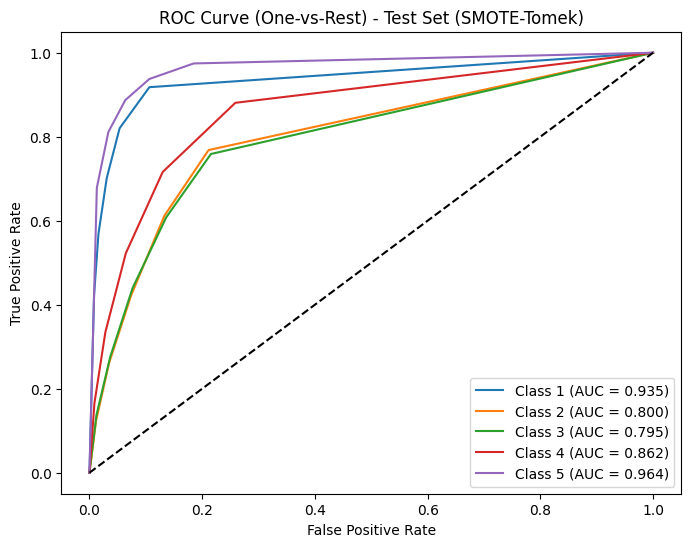

In [9]:
# =====================================
# 🧩 Cell 7: Confusion Matrix & ROC Curve
# =====================================
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.colorbar()
plt.show()

# --- 2) ROC Curve (One-vs-Rest) ---
classes = model.classes_    # ✅ ใช้ class จากโมเดลที่เทรน (เช่น KNN, SVM, RF ฯลฯ)
n_classes = len(classes)

# แปลง y_test เป็น one-hot ให้ตรงกับลำดับ class ของโมเดล
y_test_bin = label_binarize(y_test, classes=classes)

# ใช้ค่าความน่าจะเป็นจาก predict_proba
y_pred_proba_test = model.predict_proba(X_test)

# คำนวณค่า ROC/AUC ของแต่ละคลาส
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- 3) พล็อตกราฟ ROC ---
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - Test Set (SMOTE-Tomek)')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# =====================================
# 🧩 Cell 8: Save Model, AUC & ROC Data
# =====================================
from google.colab import drive
drive.mount('/content/drive')

base_path = '//content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/'

# --- Save Model ---
joblib.dump(model, base_path + '2-3knn_smote_tomek.pkl')
print(f"\n💾 Model saved as {base_path}2-3knn_smote_tomek.pkl")

# --- Save AUC per Fold + Test ---
auscsv = pd.DataFrame({
    "Fold": list(range(1, 11)) + ["Test Set"],
    "AUC_ROC": auc_scores + [test_auc]
})
auscsv.to_csv(base_path + '2-3knn_smote_tomek_auc.csv', index=False)
print(f"💾 AUC-ROC values saved to {base_path}2-3knn_smote_tomek_auc.csv")

# === คำนวณ ROC Curve ด้วย predict_proba (One-vs-Rest) ===
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd

# ใช้ classes จากโมเดลจริง
classes = model.classes_
n_classes = len(classes)

# แปลง y_test เป็น one-hot ตามลำดับ classes
y_test_bin = label_binarize(y_test, classes=classes)

# ใช้ค่า predict_proba จากโมเดล KNN
y_pred_proba_test = model.predict_proba(X_test)

# คำนวณ ROC Curve ของแต่ละคลาส
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba_test[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# (Optional) คำนวณ Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

roc_points = []
for i in range(n_classes):
    for fp, tp in zip(fpr[i], tpr[i]):
        roc_points.append({'Class': i, 'FPR': fp, 'TPR': tp})
# === Save FPR and TPR for each class ===
roc_df = pd.DataFrame(roc_points)
roc_df.to_csv(base_path + '2-3knn_smote_tomek_roc_points.csv', index=False)
print(f"💾 ROC points saved to {base_path}2-3knn_smote_tomek_roc_points.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

💾 Model saved as //content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_smote_tomek.pkl
💾 AUC-ROC values saved to //content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_smote_tomek_auc.csv


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


💾 ROC points saved to //content/drive/MyDrive/Senior_Project/roc/KNN_Roc/Class2-3/2-3knn_smote_tomek_roc_points.csv
